In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Load the dataset
df = pd.read_csv(r"C:\Users\lengu\Downloads\telco.csv")

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline


In [4]:
import xgboost as xgb
import lightgbm as lgb
#import shap

from imblearn.over_sampling import SMOTE

In [5]:
plt.style.use('ggplot') 

df.head(3)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer


In [6]:
#explore dataset
print("data information:")
print(df.info())


data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           704

Columns Description:
CustomerID: A unique ID that identifies each customer.

Gender: The customer’s gender: Male, Female

Age: The customer’s current age, in years, at the time the fiscal quarter ended.

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Married: Indicates if the customer is married: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Number of Dependents: Indicates the number of dependents that live with the customer.

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Population: A current population estimate for the entire Zip Code area.

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Quarter: The fiscal quarter that the data has been derived from (e.g. Q3).

Referred a Friend: Indicates if the customer has ever referred a friend or family member to this company: Yes, No

Number of Referrals: Indicates the number of referrals to date that the customer has made.

Tenure in Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Offer: Identifies the last marketing offer that the customer accepted, if applicable. Values include None, Offer A, Offer B, Offer C, Offer D, and Offer E.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Avg Monthly Long Distance Charges: Indicates the customer’s average long distance charges, calculated to the end of the quarter specified above.

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Avg Monthly GB Download: Indicates the customer’s average download volume in gigabytes, calculated to the end of the quarter specified above.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection Plan: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Premium Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Music: Indicates if the customer uses their Internet service to stream music from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Unlimited Data: Indicates if the customer has paid an additional monthly fee to have unlimited data downloads/uploads: Yes, No

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Total Refunds: Indicates the customer’s total refunds, calculated to the end of the quarter specified above.

Total Extra Data Charges: Indicates the customer’s total charges for extra data downloads above those specified in their plan, by the end of the quarter specified above.

Total Long Distance Charges: Indicates the customer’s total charges for long distance above those specified in their plan, by the end of the quarter specified above.

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Quarter: The fiscal quarter that the data has been derived from (e.g. Q3).

Satisfaction Score: A customer’s overall satisfaction rating of the company from 1 (Very Unsatisfied) to 5 (Very Satisfied).

Satisfaction Score Label: Indicates the text version of the score (1-5) as a text string.

Customer Status: Indicates the status of the customer at the end of the quarter: Churned, Stayed, or Joined

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

Churn Score Category: A calculation that assigns a Churn Score to one of the following categories: 0-10, 11-20, 21-30, 31-40, 41-50, 51-60, 61-70, 71-80, 81-90, and 91-100

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

CLTV Category: A calculation that assigns a CLTV value to one of the following categories: 2000-2500, 2501-3000, 3001-3500, 3501-4000, 4001-4500, 4501-5000, 5001-5500, 5501-6000, 6001-6500, and 6501-7000.

Churn Category: A high-level category for the customer’s reason for churning: Attitude, Competitor, Dissatisfaction, Other, Price. When they leave the company, all customers are asked about their reasons for leaving. Directly related to Churn Reason.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.


In [7]:
print(df.columns)

print('='*50)
#print(data.describe())
#print("missing values:")
#print(data.isnull().sum())

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')


In [8]:
print("missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

missing values:
Offer             3877
Internet Type     1526
Churn Category    5174
Churn Reason      5174
dtype: int64


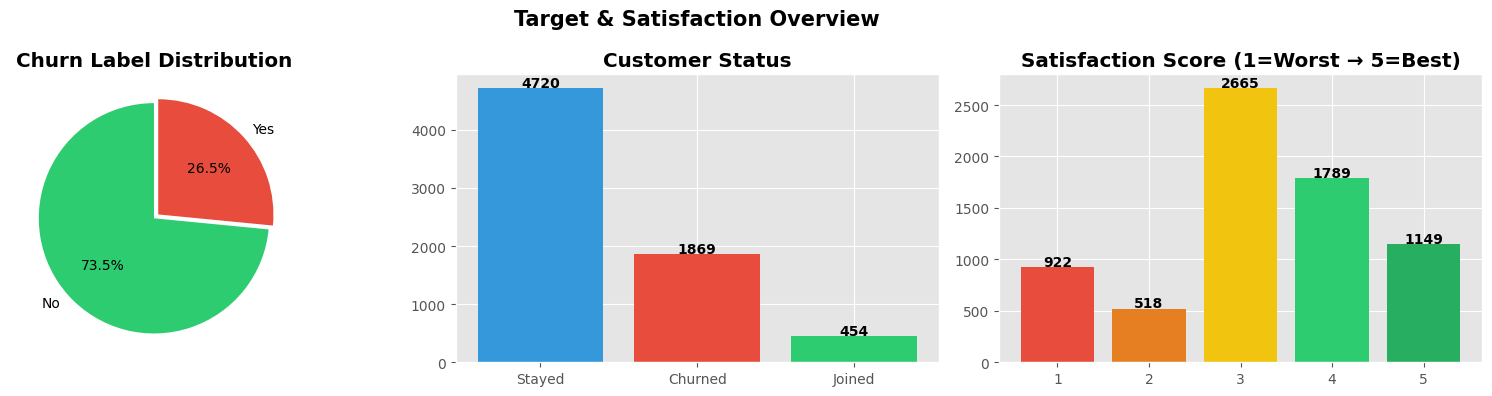


⚠️  Imbalance ratio: 2.8:1


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
churn_counts = df["Churn Label"].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index,
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0, 0.05))
axes[0].set_title("Churn Label Distribution", fontweight="bold")
 
status_counts = df["Customer Status"].value_counts()
axes[1].bar(status_counts.index, status_counts.values,
            color=["#3498db", "#e74c3c", "#2ecc71"])
axes[1].set_title("Customer Status", fontweight="bold")
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontweight="bold")
 
sat_counts = df["Satisfaction Score"].value_counts().sort_index()
axes[2].bar(sat_counts.index, sat_counts.values,
            color=["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"])
axes[2].set_title("Satisfaction Score (1=Worst → 5=Best)", fontweight="bold")
for score, cnt in sat_counts.items():
    axes[2].text(score, cnt + 15, str(cnt), ha="center", fontweight="bold")
 
plt.suptitle("Target & Satisfaction Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
#xét sự mất cân bằng của dữ liệu
print(f"\n⚠️  Imbalance ratio: {churn_counts['No']/churn_counts['Yes']:.1f}:1")

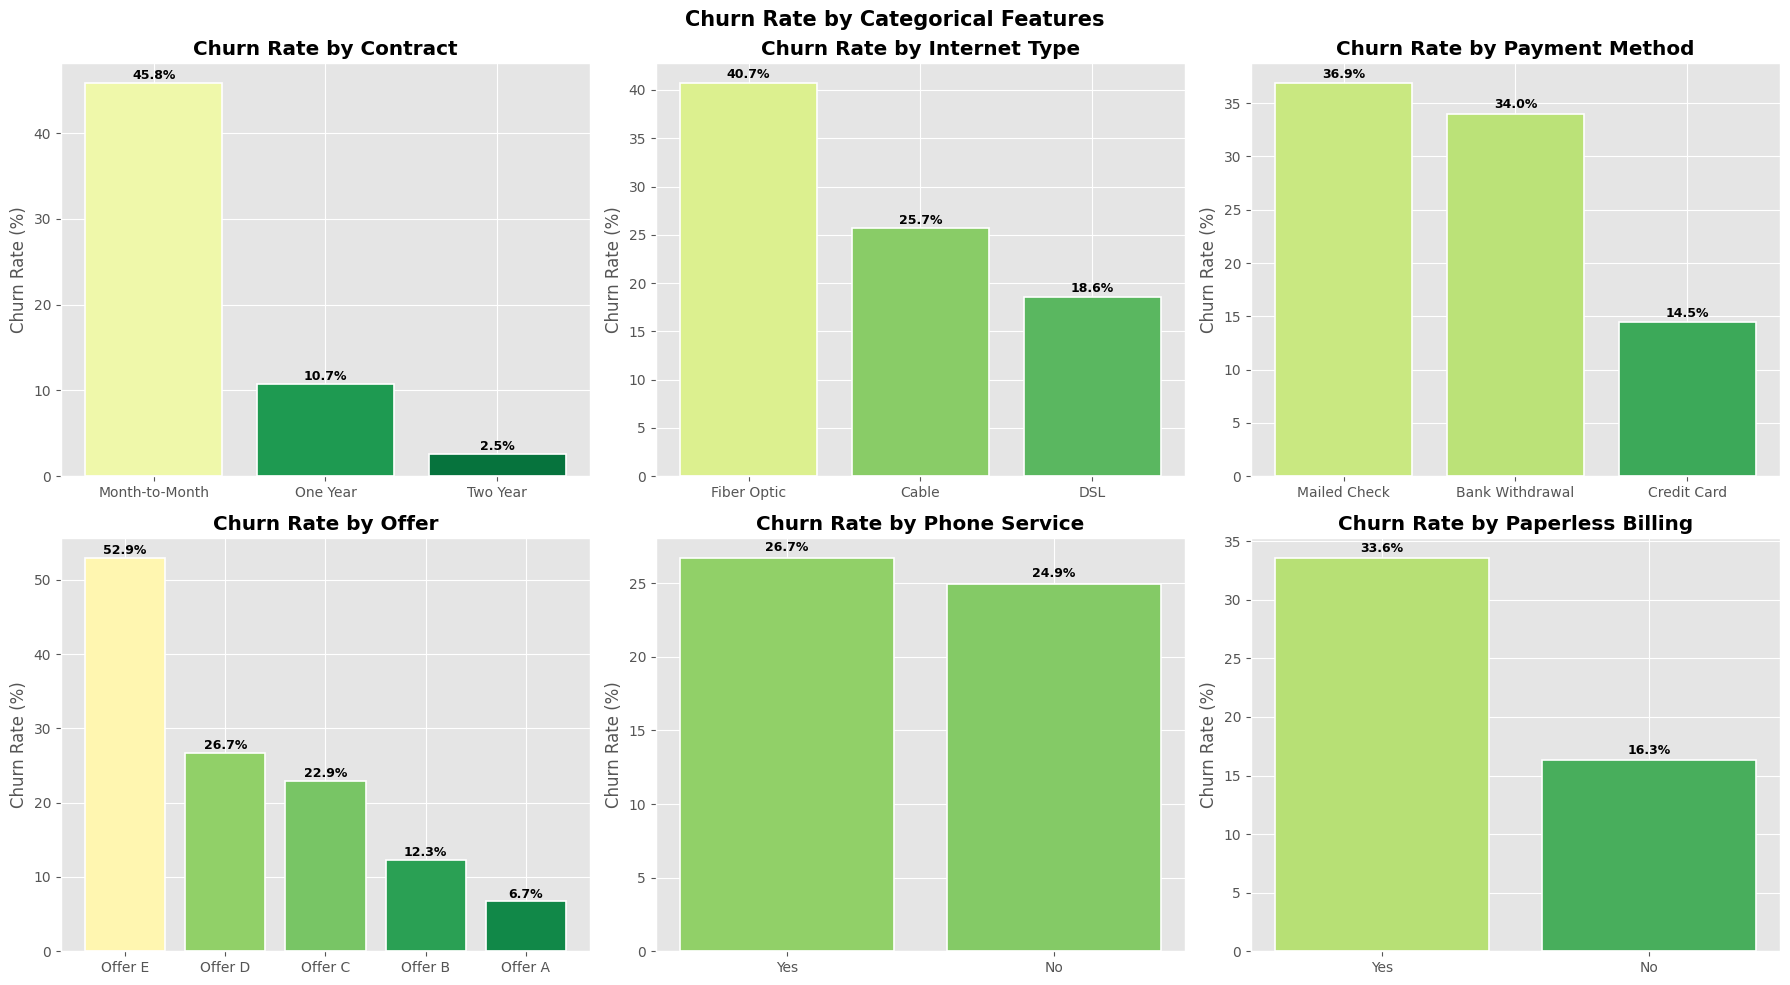

In [10]:
cat_features = [
    "Contract", "Internet Type", "Payment Method",
    "Offer", "Phone Service", "Paperless Billing"
]
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
 
for i, col in enumerate(cat_features):
    churn_rate = (
        df.groupby(col)["Churn Label"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=plt.cm.RdYlGn_r(churn_rate.values / 100),
                       edgecolor="white", linewidth=1.2)
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold")
    axes[i].set_ylabel("Churn Rate (%)")
    #axes[i].tick_params(axis="x", rotation = 30)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f"{val:.1f}%", ha="center", fontweight="bold", fontsize=9)
 
plt.suptitle("Churn Rate by Categorical Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("02_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
 

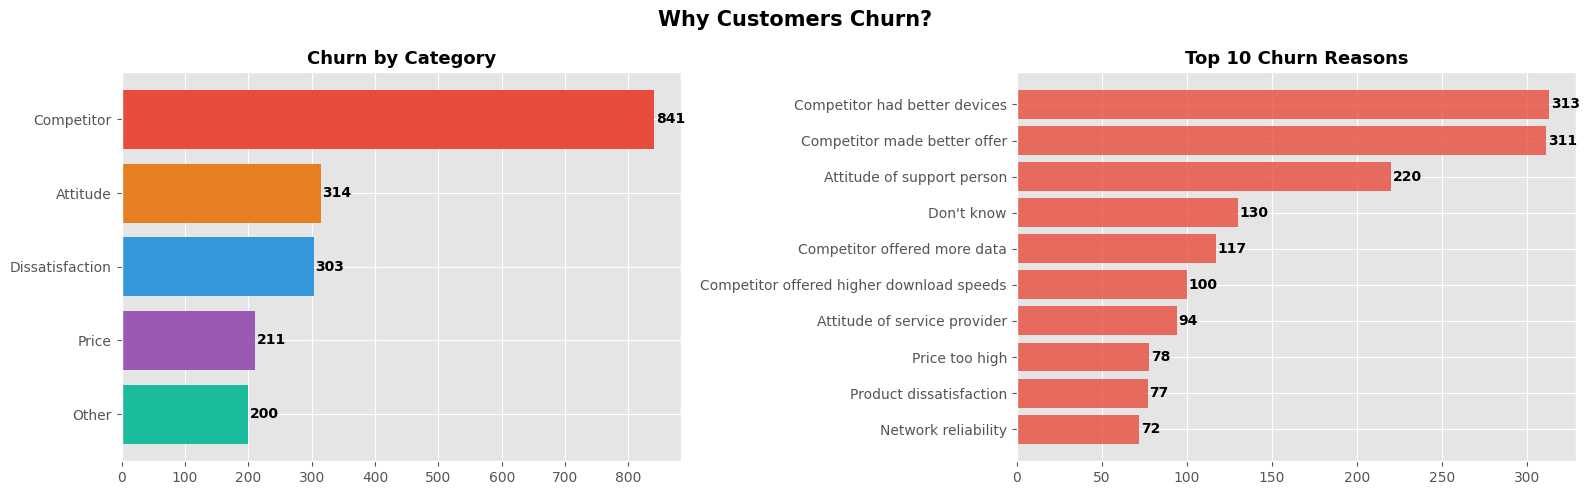

In [11]:
churned = df[df["Churn Label"] == "Yes"]
churn_reason   = churned["Churn Reason"].value_counts().head(10)
churn_category = churned["Churn Category"].value_counts()
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
axes[0].barh(churn_category.index, churn_category.values,
             color=["#e74c3c", "#e67e22", "#3498db", "#9b59b6", "#1abc9c"])
axes[0].set_title("Churn by Category", fontweight="bold", fontsize=13)
axes[0].invert_yaxis()
for i, v in enumerate(churn_category.values):
    axes[0].text(v + 3, i, str(v), va="center", fontweight="bold")
 
axes[1].barh(churn_reason.index[::-1], churn_reason.values[::-1],
             color="#e74c3c", alpha=0.8)
axes[1].set_title("Top 10 Churn Reasons", fontweight="bold", fontsize=13)
for i, v in enumerate(churn_reason.values[::-1]):
    axes[1].text(v + 1, i, str(v), va="center", fontweight="bold")
 
plt.suptitle("Why Customers Churn?", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("04_churn_reasons.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
df['Offer'] = df['Offer'].fillna('None')
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service')

In [14]:
cols_to_drop = ['Customer ID', 'Country', 'State', 'Customer Status', 
                'Churn Category', 'Churn Reason', 'Churn Score', 'Quarter']
df_clean = df.drop(columns=cols_to_drop)

In [15]:
df_clean['Churn Label'] = df_clean['Churn Label'].map({'Yes': 1, 'No': 0})

In [16]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [17]:
X = df_encoded.drop('Churn Label', axis=1)
y = df_encoded['Churn Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Phân phối nhãn trên tập Train TRƯỚC SMOTE:")
print(y_train.value_counts())
print("\nPhân phối nhãn trên tập Train SAU SMOTE:")
print(y_train_sm.value_counts())

Phân phối nhãn trên tập Train TRƯỚC SMOTE:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Phân phối nhãn trên tập Train SAU SMOTE:
Churn Label
0    4139
1    4139
Name: count, dtype: int64


=========== Logistic Regression ===========
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1035
           1       0.73      0.86      0.79       374

    accuracy                           0.88      1409
   macro avg       0.84      0.87      0.85      1409
weighted avg       0.89      0.88      0.88      1409

ROC-AUC Score: 0.9450

=========== XGBoost ===========
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1035
           1       0.97      0.91      0.94       374

    accuracy                           0.97      1409
   macro avg       0.97      0.95      0.96      1409
weighted avg       0.97      0.97      0.97      1409

ROC-AUC Score: 0.9915

=========== LightGBM ===========
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.96      0.90      0.93       374

    accuracy               

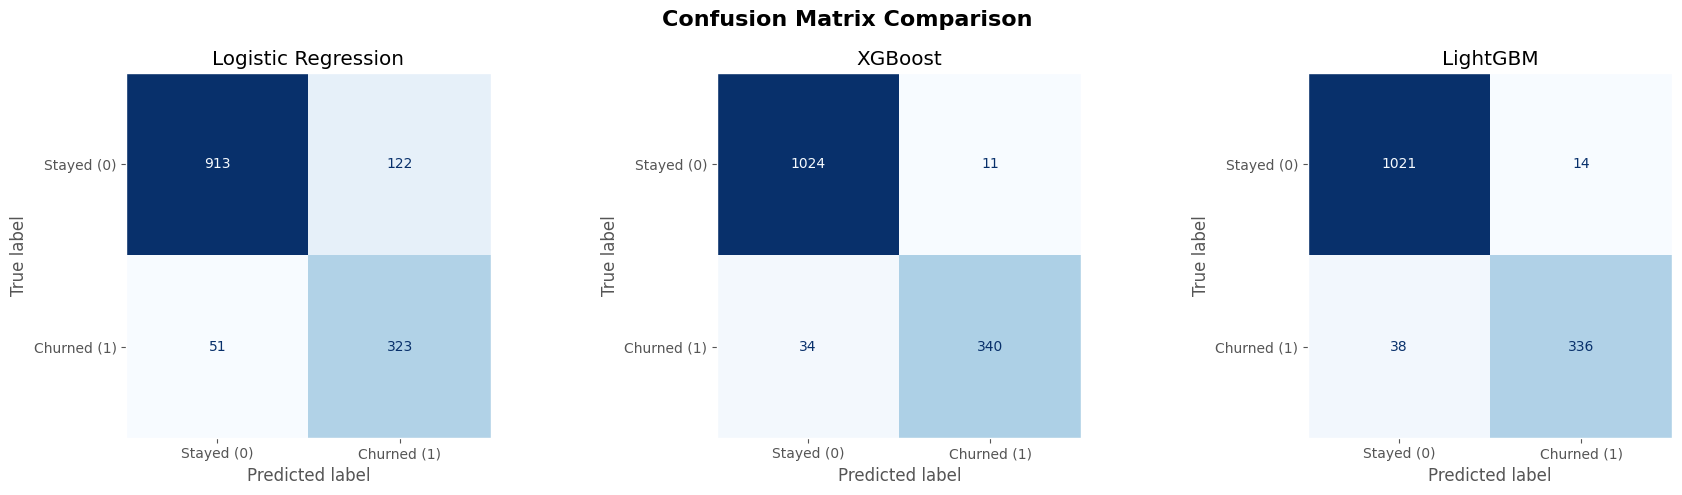

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
}

# Khung vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # Huấn luyện mô hình
    model.fit(X_train_sm, y_train_sm)
    
    # Dự đoán trên tập Test
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # In báo cáo kết quả
    print(f"=========== {name} ===========")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed (0)', 'Churned (1)']).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}')
    axes[i].grid(False)

plt.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

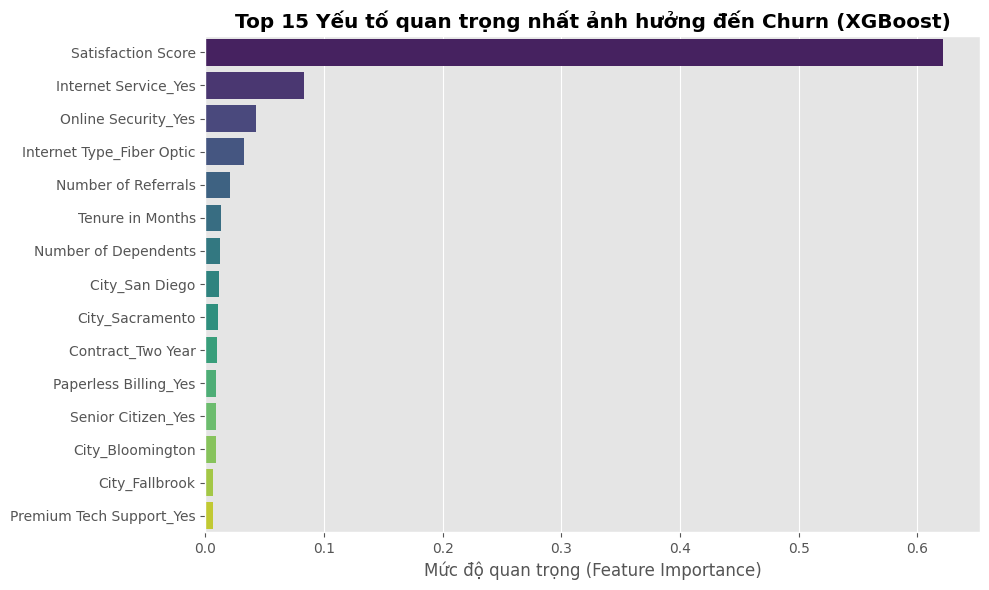

In [19]:
# Lấy mô hình XGBoost (hay cho kết quả Feature Importance tốt)
xgb_model = models['XGBoost']
importances = xgb_model.feature_importances_

# Tạo DataFrame chứa độ quan trọng của các đặc trưng
feat_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Trực quan hóa Top 15 Feature quan trọng nhất
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(15), palette='viridis')
plt.title('Top 15 Yếu tố quan trọng nhất ảnh hưởng đến Churn (XGBoost)', fontweight='bold')
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.ylabel('')
plt.tight_layout()
plt.show()